In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data" / "raw"

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
description_path = DATA_DIR / "data_description.txt"
sample_submission_path = DATA_DIR / "sample_submission.csv"

print("Train path:", train_path)
print("Test path:", test_path)
print("Description path:", description_path)
print("Sample submission path:", sample_submission_path)

Train path: c:\Users\Admin\OneDrive\Рабочий стол\ML\house_price_prediction\data\raw\train.csv
Test path: c:\Users\Admin\OneDrive\Рабочий стол\ML\house_price_prediction\data\raw\test.csv
Description path: c:\Users\Admin\OneDrive\Рабочий стол\ML\house_price_prediction\data\raw\data_description.txt
Sample submission path: c:\Users\Admin\OneDrive\Рабочий стол\ML\house_price_prediction\data\raw\sample_submission.csv


In [4]:
print("train.csv exists:", train_path.exists())
print("test.csv exists:", test_path.exists())
print("data_description.txt exists:", description_path.exists())
print("sample_submission.csv exists:", sample_submission_path.exists())

train.csv exists: True
test.csv exists: True
data_description.txt exists: True
sample_submission.csv exists: True


In [5]:
df = pd.read_csv(train_path)

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
print("Размер датасета: ", df.shape)

Размер датасета:  (1460, 81)


In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

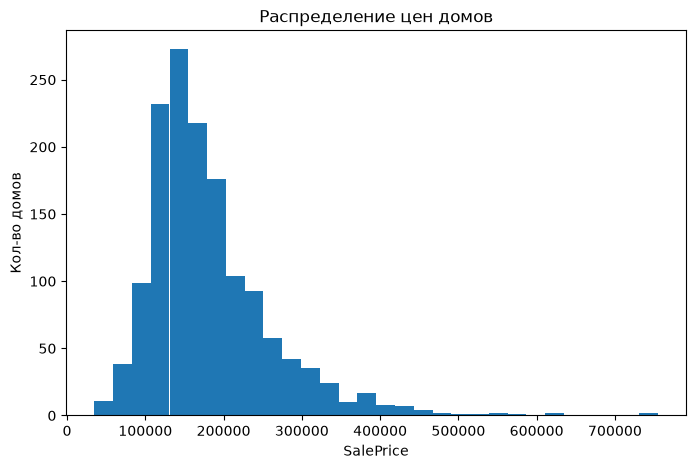

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["SalePrice"], bins=30)

plt.xlabel("SalePrice")
plt.ylabel("Кол-во домов")
plt.title("Распределение цен домов")

plt.show()



## EDA: пропуски, типы признаков и связь с ценой

In [14]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [17]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
        "missing_values": missing_values,
        "missing_percent": missing_percent
    })
missing_df.head(20)


,missing_values,missing_percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


In [24]:
target = "SalePrice"

numeric_features = df.drop(columns=[target]).select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.drop(columns=[target]).select_dtypes(include=["object"]).columns

print("Кол-во числовых признаков: ", len(numeric_features))
print("Кол-во категориальных признаков: ", len(categorical_features))

Кол-во числовых признаков:  37
Кол-во категориальных признаков:  43


C:\Users\Admin\AppData\Local\Temp\ipykernel_19988\2063185455.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.drop(columns=[target]).select_dtypes(include=["object"]).columns


In [23]:
df[numeric_features].head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,548,0,61,0,0,0,0,0,2,2008
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,460,298,0,0,0,0,0,0,5,2007
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,608,0,42,0,0,0,0,0,9,2008
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,642,0,35,272,0,0,0,0,2,2006
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,836,192,84,0,0,0,0,0,12,2008


In [26]:
df[categorical_features].head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [30]:
correlations = df.select_dtypes(include=["int64", "float64"]).corr()["SalePrice"]

correlations = correlations.sort_values(ascending=False)

correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

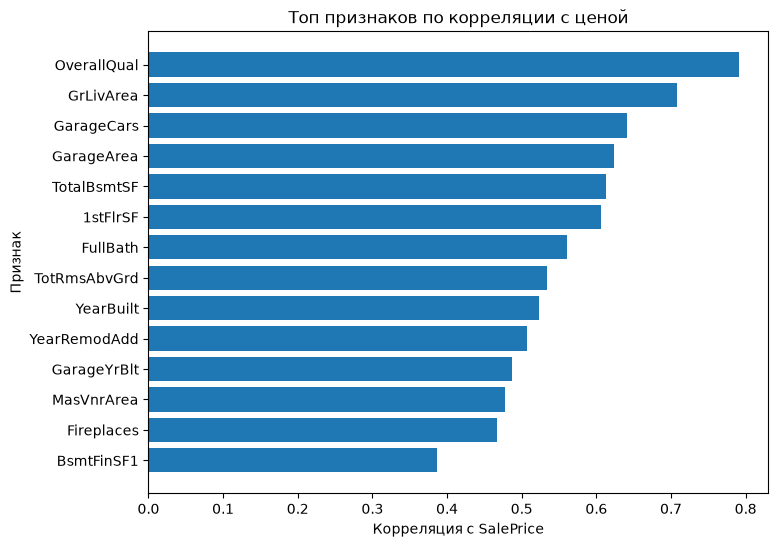

In [33]:
top_corr = correlations.head(15).drop("SalePrice")

plt.figure(figsize=(8, 6))

plt.barh(top_corr.index, top_corr.values)

plt.xlabel("Корреляция с SalePrice")
plt.ylabel("Признак")
plt.title("Топ признаков по корреляции с ценой")

plt.gca().invert_yaxis()
plt.show()

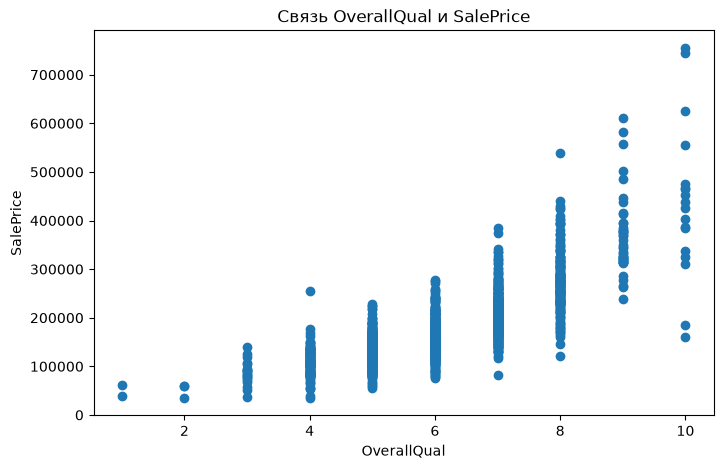

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(df["OverallQual"], df["SalePrice"])

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Связь OverallQual и SalePrice")

plt.show()

In [35]:
quality_price = df.groupby("OverallQual")["SalePrice"].mean()

quality_price

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

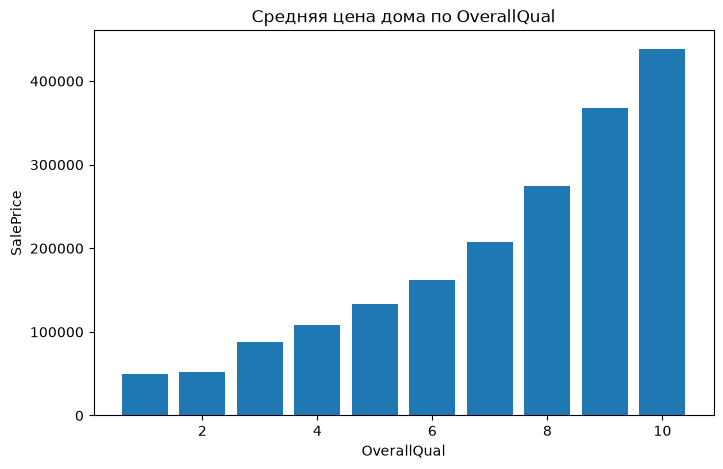

In [37]:
plt.figure(figsize=(8,5))

plt.bar(quality_price.index, quality_price.values)

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Средняя цена дома по OverallQual")

plt.show()

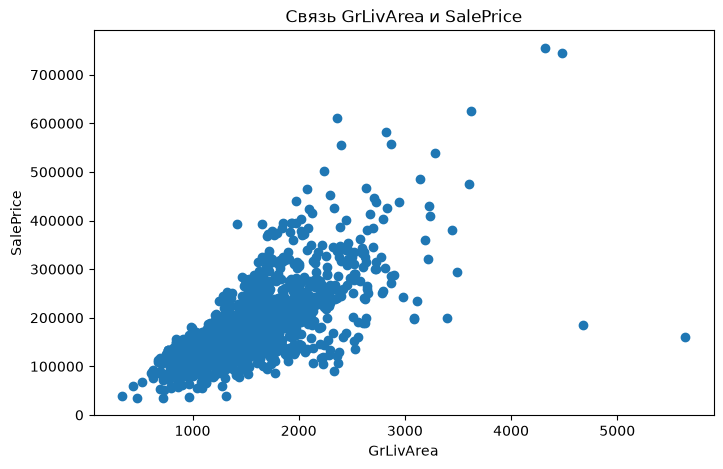

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Связь GrLivArea и SalePrice")

plt.show()

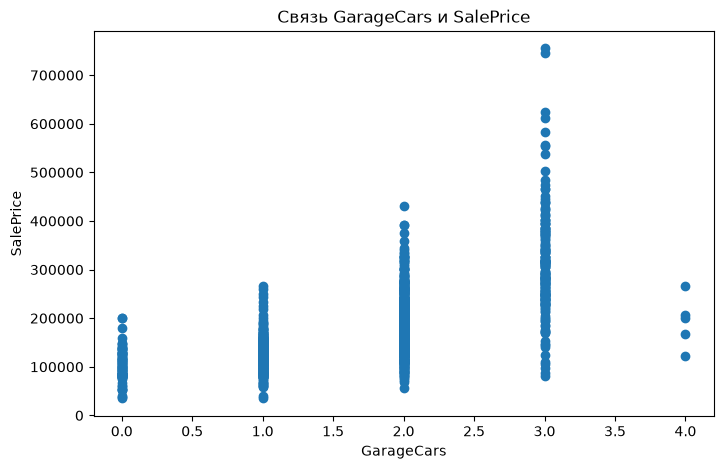

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df["GarageCars"], df["SalePrice"])

plt.xlabel("GarageCars")
plt.ylabel("SalePrice")
plt.title("Связь GarageCars и SalePrice")

plt.show()

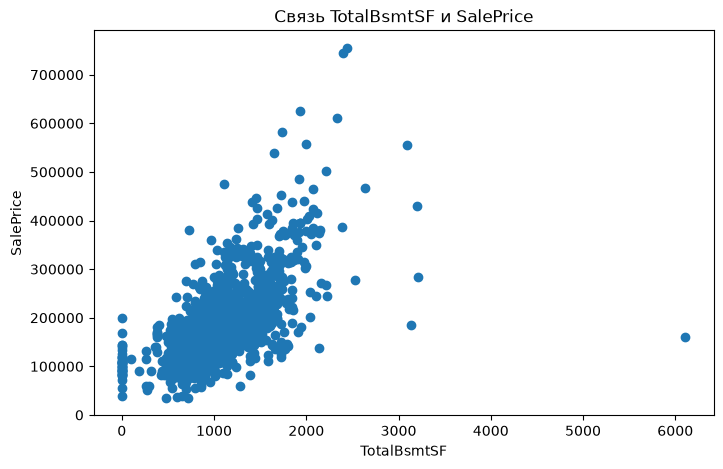

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(df["TotalBsmtSF"], df["SalePrice"])

plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.title("Связь TotalBsmtSF и SalePrice")

plt.show()

## Подготовка данных для модели


In [44]:
target = "SalePrice"

X = df.drop(columns=[target])
y = df[target]

print("X shape: ", X.shape)
print("Y shape: ", y.shape)


X shape:  (1460, 80)
Y shape:  (1460,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (1168, 80)
X_test:  (292, 80)
y_train:  (1168,)
y_test:  (292,)


In [47]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns 
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Кол-во числовых признаков: ", len(numeric_features))
print("Кол-во категориальных признаков: ", len(categorical_features))

Кол-во числовых признаков:  37
Кол-во категориальных признаков:  43


C:\Users\Admin\AppData\Local\Temp\ipykernel_19988\3247858480.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


In [48]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [49]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



In [50]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [51]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

In [52]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

evaluate_model("Baseline TEST", y_test, baseline_pred)

Baseline TEST
MAE: 62575.926451960964
MSE: 7677095207.783831
RMSE: 87619.03450611533
R2: -0.0008824918802490256


In [53]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


In [55]:
linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [56]:
linear_pred = linear_model.predict(X_test)


In [57]:
evaluate_model("Linear Regression TEST", y_test, linear_pred)

Linear Regression TEST
MAE: 18284.677599210932
MSE: 868845459.5436091
RMSE: 29476.18461645959
R2: 0.8867264004066089


In [60]:
results = []

def add_result(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    
    results.append({
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    })


add_result("Baseline", y_test, baseline_pred)
add_result("Linear Regression", y_test, linear_pred)

results_df = pd.DataFrame(results)

results_df.sort_values(by="RMSE")

,model,MAE,MSE,RMSE,R2
1,Linear Regression,18284.677599,8.688455e+08,29476.184616,0.886726
0,Baseline,62575.926452,7.677095e+09,87619.034506,-0.000882


In [61]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

evaluate_model("Ridge model TEST", y_test, ridge_pred)



Ridge model TEST
MAE: 19006.271311093886
MSE: 890679345.3965806
RMSE: 29844.251463164233
R2: 0.8838798609944372


In [62]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

evaluate_model("Lasso Regression TEST", y_test, lasso_pred)

Lasso Regression TEST
MAE: 18011.483887691713
MSE: 804353058.1245941
RMSE: 28361.11877420554
R2: 0.8951344393448466


In [63]:
add_result("Ridge", y_test, ridge_pred)
add_result("Lasso", y_test, lasso_pred)

results_df = pd.DataFrame(results)

results_df.sort_values(by="RMSE")

,model,MAE,MSE,RMSE,R2
3,Lasso,18011.483888,8.043531e+08,28361.118774,0.895134
1,Linear Regression,18284.677599,8.688455e+08,29476.184616,0.886726
2,Ridge,19006.271311,8.906793e+08,29844.251463,0.883880
0,Baseline,62575.926452,7.677095e+09,87619.034506,-0.000882


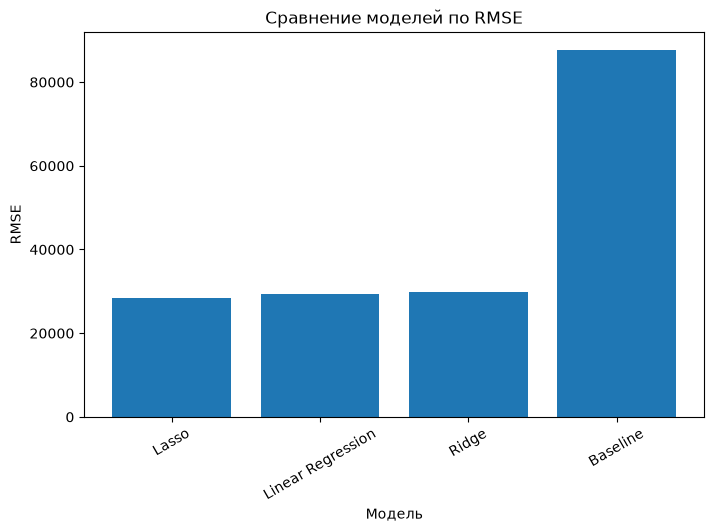

In [64]:
results_df_sorted = results_df.sort_values(by="RMSE")

plt.figure(figsize=(8,5))

plt.bar(results_df_sorted["model"], results_df_sorted["RMSE"])

plt.xlabel("Модель")
plt.ylabel("RMSE")
plt.title("Сравнение моделей по RMSE")

plt.xticks(rotation=30)

plt.show()

## Выводы по первым моделям

На графике сравнивается качество первых моделей по метрике RMSE. Чем ниже значение RMSE, тем лучше модель предсказывает цену дома.

Baseline-модель показала самый высокий RMSE. Это ожидаемо, так как DummyRegressor всегда предсказывает среднее значение цены и не использует признаки дома.

LinearRegression, Ridge и Lasso показали значительно более низкую ошибку по сравнению с baseline. Это означает, что признаки датасета содержат полезную информацию для предсказания `SalePrice`.

Лучший результат среди первых моделей показала Lasso Regression. Ridge и LinearRegression дали близкие значения RMSE, поэтому на данном этапе регуляризация Ridge не дала заметного улучшения качества.

Таким образом, первые ML-модели уже значительно превосходят baseline. В качестве следующего шага нужно подобрать гиперпараметры для Ridge и Lasso через GridSearchCV, а затем сравнить линейные модели с более сложными алгоритмами, например RandomForestRegressor и HistGradientBoostingRegressor.

## Подбор гиперпараметров через GridSearchCV

In [66]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha" : [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Лучшие параметры Ridge: ", ridge_grid.best_params_)
print("Лучший CV RMSE: ", -ridge_grid.best_score_)


Лучшие параметры Ridge:  {'model__alpha': 10}
Лучший CV RMSE:  32585.456980970303


In [67]:
best_ridge_model = ridge_grid.best_estimator_

best_ridge_pred = best_ridge_model.predict(X_test)

evaluate_model("Best Ridge TEST", y_test, best_ridge_pred)


Best Ridge TEST
MAE: 19021.27376284733
MSE: 939743282.1009561
RMSE: 30655.232540317746
R2: 0.8774832703698556


In [70]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Лучшие параметры Lasso:", lasso_grid.best_params_)
print("Лучший CV RMSE:", -lasso_grid.best_score_)

Лучшие параметры Lasso: {'model__alpha': 100}
Лучший CV RMSE: 32558.444516040712


In [71]:
best_lasso_model = lasso_grid.best_estimator_

best_lasso_pred = best_lasso_model.predict(X_test)

evaluate_model("Best Lasso TEST", y_test, best_lasso_pred)


Best Lasso TEST
MAE: 17101.99325925663
MSE: 805893332.6536772
RMSE: 28388.260472485403
R2: 0.894933629824172


In [72]:
def get_metrics(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

final_linear_results = pd.DataFrame([
    get_metrics("Baseline", y_test, baseline_pred),
    get_metrics("Linear Regression", y_test, linear_pred),
    get_metrics("Ridge", y_test, ridge_pred),
    get_metrics("Lasso", y_test, lasso_pred),
    get_metrics("Best Ridge GridSearch", y_test, best_ridge_pred),
    get_metrics("Best Lasso GridSearch", y_test, best_lasso_pred)
])

final_linear_results.sort_values(by="RMSE")

,model,MAE,MSE,RMSE,R2
3,Lasso,18011.483888,8.043531e+08,28361.118774,0.895134
5,Best Lasso GridSearch,17101.993259,8.058933e+08,28388.260472,0.894934
1,Linear Regression,18284.677599,8.688455e+08,29476.184616,0.886726
2,Ridge,19006.271311,8.906793e+08,29844.251463,0.883880
4,Best Ridge GridSearch,19021.273763,9.397433e+08,30655.232540,0.877483
0,Baseline,62575.926452,7.677095e+09,87619.034506,-0.000882


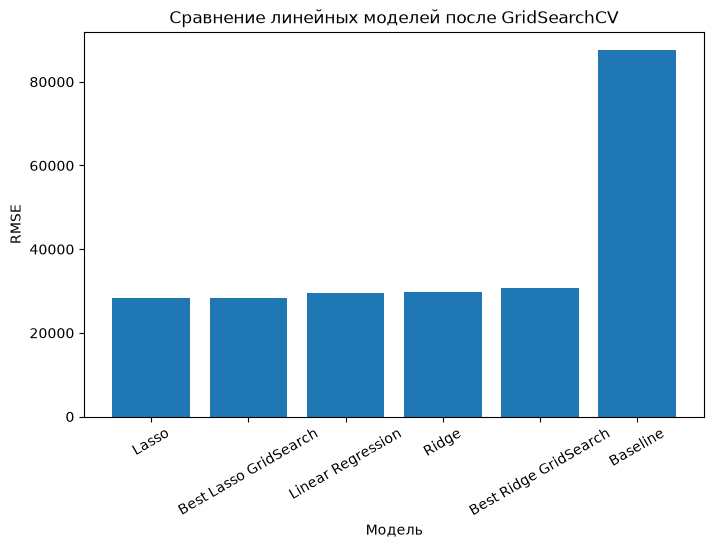

In [73]:
final_linear_results_sorted = final_linear_results.sort_values(by="RMSE")

plt.figure(figsize=(8,5))

plt.bar(
    final_linear_results_sorted["model"],
    final_linear_results_sorted["RMSE"]
)

plt.xlabel("Модель")
plt.ylabel("RMSE")
plt.title("Сравнение линейных моделей после GridSearchCV")
plt.xticks(rotation=30)

plt.show()

## Выводы по сравнению линейных моделей

На данном этапе были обучены и сравнены несколько базовых моделей для задачи предсказания стоимости домов: DummyRegressor, LinearRegression, Ridge и Lasso.

Baseline-модель показала самый высокий RMSE — около 87 600. Это ожидаемо, так как DummyRegressor всегда предсказывает среднее значение цены и не использует признаки объектов.

Все линейные модели значительно превзошли baseline. Это означает, что признаки датасета содержат полезную информацию для предсказания `SalePrice`.

Лучший результат по RMSE показала модель Lasso: RMSE составил около 28 361, а R2 около 0.895. Это говорит о том, что модель объясняет значительную часть разброса цен домов.

Lasso после GridSearchCV показала практически такой же результат: RMSE около 28 388. Разница между обычной Lasso и Best Lasso GridSearch минимальна, поэтому можно считать, что обе модели работают примерно одинаково.

Ridge и LinearRegression также показали качество значительно выше baseline, однако уступили Lasso. Это может говорить о том, что Lasso лучше справляется с большим количеством признаков после OneHotEncoder и может занулять менее полезные признаки.

Таким образом, среди линейных моделей наиболее перспективной на данном этапе является Lasso. Следующим шагом будет сравнение линейных моделей с более сложными алгоритмами, такими как RandomForestRegressor и HistGradientBoostingRegressor.

## RandomForestRegressor

In [74]:
tree_numeric_transformer = ([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_transformer = ([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

tree_preprocessor = ColumnTransformer([
    ("num", tree_numeric_transformer, numeric_features),
    ("cat", tree_categorical_transformer, categorical_features)
])


In [75]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
])

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

evaluate_model("Random Forest TEST", y_test, rf_pred)


Random Forest TEST
MAE: 17467.572157534247
MSE: 816407686.1758959
RMSE: 28572.848758496166
R2: 0.8935628467260077


In [80]:
final_results_with_rf = pd.concat([
    final_linear_results,
    pd.DataFrame([
        get_metrics("Random Forest", y_test, rf_pred)
    ])
])

final_results_with_rf.sort_values(by="RMSE")

,model,MAE,MSE,RMSE,R2
3,Lasso,18011.483888,8.043531e+08,28361.118774,0.895134
5,Best Lasso GridSearch,17101.993259,8.058933e+08,28388.260472,0.894934
0,Random Forest,17467.572158,8.164077e+08,28572.848758,0.893563
1,Linear Regression,18284.677599,8.688455e+08,29476.184616,0.886726
2,Ridge,19006.271311,8.906793e+08,29844.251463,0.883880
4,Best Ridge GridSearch,19021.273763,9.397433e+08,30655.232540,0.877483
0,Baseline,62575.926452,7.677095e+09,87619.034506,-0.000882


In [81]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Лучшие параметры RandomForest:")
print(rf_random_search.best_params_)

print("Лучший CV RMSE:", -rf_random_search.best_score_)

Лучшие параметры RandomForest:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}
Лучший CV RMSE: 28953.185236474543


In [82]:
best_rf_model = rf_random_search.best_estimator_

best_rf_pred = best_rf_model.predict(X_test)

evaluate_model("Best Random Forest RandomizedSearch TEST", y_test, best_rf_pred)

Best Random Forest RandomizedSearch TEST
MAE: 17417.49244688944
MSE: 840828928.5136173
RMSE: 28997.050341605736
R2: 0.8903789870467624


In [85]:
final_results_with_best_rf = pd.concat([
    final_results_with_rf,
    pd.DataFrame([
        get_metrics("Best Random Forest RandomizedSearch", y_test, best_rf_pred)
    ])
])

final_results_with_best_rf.sort_values(by="RMSE")


,model,MAE,MSE,RMSE,R2
3,Lasso,18011.483888,8.043531e+08,28361.118774,0.895134
5,Best Lasso GridSearch,17101.993259,8.058933e+08,28388.260472,0.894934
0,Random Forest,17467.572158,8.164077e+08,28572.848758,0.893563
0,Best Random Forest RandomizedSearch,17417.492447,8.408289e+08,28997.050342,0.890379
1,Linear Regression,18284.677599,8.688455e+08,29476.184616,0.886726
2,Ridge,19006.271311,8.906793e+08,29844.251463,0.883880
4,Best Ridge GridSearch,19021.273763,9.397433e+08,30655.232540,0.877483
0,Baseline,62575.926452,7.677095e+09,87619.034506,-0.000882


## HistGradientBoostingRegressor